In [76]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("../../../data/Train/train.csv", delimiter=";")
df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11
1,abfdd1,2025-01-01 12:53:57.851,2025-01-01 12:54:15.692,2025-01-01 12:55:08.113,70.262,Heavy (larger than 136000 kg),-3.572788,40.491846,-3.573818,40.491858,Z3,False,18R/36L,2025-01-01,12
2,4cacdf,2025-01-01 10:20:25.104,2025-01-01 10:20:38.071,2025-01-01 10:21:24.027,58.923,Medium 2 (between 34000 kg to 136000 kg),-3.561172,40.501179,-3.560085,40.501343,Y3,False,18L/36R,2025-01-01,10
3,34754c,2025-01-01 05:37:49.944,2025-01-01 05:38:03.062,2025-01-01 05:38:52.151,62.207,Medium 2 (between 34000 kg to 136000 kg),-3.576462,40.492481,-3.575488,40.492766,Z4,False,18R/36L,2025-01-01,5
4,34754c,2025-01-01 12:45:58.757,2025-01-01 12:46:16.737,2025-01-01 12:48:41.019,162.262,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492475,-3.575519,40.492777,Z4,False,18R/36L,2025-01-01,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44273,4ca8d4,2024-12-26 12:27:51.855,2024-12-26 12:28:20.716,2024-12-26 12:29:38.229,106.374,Medium 2 (between 34000 kg to 136000 kg),-3.561209,40.499504,-3.560148,40.499702,Y1,False,18L/36R,2024-12-26,12
44274,4ca8d4,2024-12-26 19:20:58.493,2024-12-26 19:21:27.415,2024-12-26 19:23:29.475,150.982,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492498,-3.575488,40.492754,Z4,False,18R/36L,2024-12-26,19
44275,3c64a8,2024-12-26 06:52:59.064,2024-12-26 06:53:26.693,2024-12-26 06:54:36.374,97.310,Medium 2 (between 34000 kg to 136000 kg),-3.561193,40.500296,-3.560070,40.500470,Y2,False,18L/36R,2024-12-26,6
44276,44cdd1,2024-12-26 16:47:01.673,2024-12-26 16:47:19.837,2024-12-26 16:48:19.333,77.660,Medium 2 (between 34000 kg to 136000 kg),-3.576248,40.491554,-3.575363,40.492081,Z2,False,18R/36L,2024-12-26,16


In [77]:
df.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue'],
      dtype='object')

In [78]:
import pandas as pd
import numpy as np

def procesar_datos(df):
    df = df.copy()

    # --- Timestamps ---
    df["llegada_punto"] = pd.to_datetime(df["llegada_punto"])
    df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"], errors="coerce")

    # Hora en segundos desde medianoche
    df["segundos_llegada"] = df["llegada_punto"].dt.hour * 3600 + df["llegada_punto"].dt.minute * 60 + df["llegada_punto"].dt.second

    # Día de la semana (0=lunes, 6=domingo)
    df["dia_semana"] = df["fecha_despegue"].dt.weekday

    # Codificar si es fin de semana
    df["es_finde"] = df["dia_semana"] >= 5

    # --- Categóricas como one-hot ---
    df = pd.get_dummies(df, columns=["aircraft_type", "holding_point"], drop_first=True)

    # --- Booleanas ---
    df["parado"] = df["parado"].astype(int)
    df["es_finde"] = df["es_finde"].astype(int)

    # --- Variables finales ---
    columnas_finales = ["segundos_llegada", "dia_semana", "es_finde", "parado"] + \
                       [col for col in df.columns if col.startswith("aircraft_type_") or col.startswith("holding_point_")]

    x = df[columnas_finales].values.astype(np.float32)
    y = df["tiempo_espera"].values.astype(np.float32)

    umbral = 500  # segundos
    mask = y < umbral

    x = x[mask]
    y = y[mask]

    mask = y > 0
    x = x[mask]
    y = y[mask]

    return x, y, columnas_finales

In [79]:
x, y, columnas = procesar_datos(df)

In [80]:
columnas

['segundos_llegada',
 'dia_semana',
 'es_finde',
 'parado',
 'aircraft_type_High vortex aircraft',
 'aircraft_type_Light (less than 7000 kg)',
 'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
 'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
 'holding_point_K2',
 'holding_point_K3',
 'holding_point_KA6',
 'holding_point_KA8',
 'holding_point_L1',
 'holding_point_LA',
 'holding_point_LB',
 'holding_point_LC',
 'holding_point_LD',
 'holding_point_LE',
 'holding_point_LF',
 'holding_point_Y1',
 'holding_point_Y2',
 'holding_point_Y3',
 'holding_point_Z1',
 'holding_point_Z2',
 'holding_point_Z3',
 'holding_point_Z4',
 'holding_point_Z6']

In [81]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

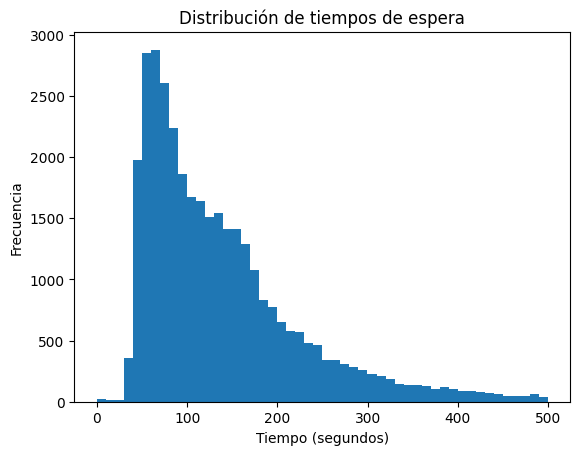

In [82]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50)
plt.title("Distribución de tiempos de espera")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Frecuencia")
plt.show()

In [83]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

def modelo_regresion(x, y=None):
    n_features = x.shape[1]

    # Priores para los coeficientes y bias
    beta = numpyro.sample("beta", dist.Normal(0, 1).expand([n_features]))
    intercept = numpyro.sample("intercept", dist.Normal(0, 5))
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))  # escala del LogNormal

    # Predicción media (log del tiempo esperado)
    mu = intercept + jnp.dot(x, beta)

    # Tiempo de espera ~ LogNormal(mu, sigma)
    numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y)

In [84]:
from numpyro.infer import MCMC, NUTS

rng_key = jax.random.PRNGKey(0)
kernel = NUTS(modelo_regresion)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000)
mcmc.run(rng_key, x=x_train, y=y_train)
mcmc.print_summary()

sample: 100%|██████████| 2000/2000 [23:56<00:00,  1.39it/s, 1023 steps of size 6.07e-05. acc. prob=0.92]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
    beta[0]      0.00      0.00      0.00      0.00      0.00      3.05      2.43
    beta[1]      0.50      0.01      0.50      0.49      0.51      4.33      1.72
    beta[2]     -1.21      0.00     -1.21     -1.21     -1.20      3.24      3.26
    beta[3]      0.18      0.02      0.18      0.15      0.20      2.83      2.77
    beta[4]     -1.14      0.00     -1.14     -1.14     -1.13      6.09      1.43
    beta[5]      0.86      0.00      0.86      0.86      0.86      5.82      1.00
    beta[6]     -1.54      0.00     -1.54     -1.55     -1.54      3.94      1.74
    beta[7]     -1.19      0.06     -1.19     -1.27     -1.10      2.84      2.71
    beta[8]     -0.42      0.00     -0.42     -0.42     -0.42      2.81      2.94
    beta[9]     -0.58      0.00     -0.58     -0.58     -0.57      5.89      1.17
   beta[10]     -0.12      0.00     -0.11     -0.12     -0.11      3.23      2.05
   beta[11]    

In [85]:
from numpyro.infer import Predictive

# Predictive posterior
predictive = Predictive(modelo_regresion, posterior_samples=mcmc.get_samples(), return_sites=["obs"])
preds = predictive(jax.random.PRNGKey(1), x=x_test)

# Media y percentiles
y_pred_mean = jnp.mean(preds["obs"], axis=0)
y_pred_lower = jnp.percentile(preds["obs"], 5, axis=0)
y_pred_upper = jnp.percentile(preds["obs"], 95, axis=0)

In [86]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_mean)
print("MAE:", mae)

# Opcional: imprimir algunos intervalos de confianza
for i in range(5):
    print(f"Ejemplo {i}: predicho {y_pred_mean[i]:.1f}s (95% CI: {y_pred_lower[i]:.1f} - {y_pred_upper[i]:.1f}), real: {y_test[i]:.1f}s")


MAE: 837.548583984375
Ejemplo 0: predicho 789.4s (95% CI: 14.2 - 3225.9), real: 323.4s
Ejemplo 1: predicho 158.7s (95% CI: 3.1 - 564.8), real: 102.1s
Ejemplo 2: predicho 701.7s (95% CI: 10.9 - 2698.6), real: 34.0s
Ejemplo 3: predicho 2470.8s (95% CI: 45.0 - 9062.4), real: 81.2s
Ejemplo 4: predicho 348.4s (95% CI: 5.3 - 1395.9), real: 161.5s


In [87]:
# import jax.numpy as jnp
# import numpyro
# import numpyro.distributions as dist

# def modelo_aviones(x, punto_id, y_obs=None, num_puntos=5, num_pistas=3):
#     N, D = x.shape  # N datos, D variables

#     # Priori para probabilidades de pistas por punto de espera (categorical prior)
#     with numpyro.plate("puntos", num_puntos):
#         pi = numpyro.sample("pi", dist.Dirichlet(jnp.ones(num_pistas)))

#     # Intercepto por punto de espera
#     with numpyro.plate("alpha_puntos", num_puntos):
#         alpha = numpyro.sample("alpha", dist.Normal(0, 1))

#     # Efecto por pista (latente)
#     with numpyro.plate("pistas", num_pistas):
#         gamma = numpyro.sample("gamma", dist.Normal(0, 1))

#     # Coeficientes para covariables
#     beta = numpyro.sample("beta", dist.Normal(0, 1).expand([D]))

#     # Desviación estándar
#     sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

#     with numpyro.plate("datos", N):
#         # Variable latente: pista asignada
#         z = numpyro.sample("z", dist.Categorical(probs=pi[punto_id]))

#         # Media para cada observación
#         mu = alpha[punto_id] + gamma[z] + jnp.sum(x * beta, axis=1)

#         # Modelo del tiempo de espera
#         numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y_obs)


In [88]:
# from numpyro.infer import MCMC, NUTS
# import jax.random as random

# # Supongamos que ya tienes: x, punto_id, y_obs
# # x: (N, D), punto_id: (N,), y_obs: (N,)
# rng_key = random.PRNGKey(0)

# kernel = NUTS(modelo_aviones)
# mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
# mcmc.run(rng_key, x=x, punto_id=punto_id, y_obs=y_obs,
#          num_puntos=num_puntos, num_pistas=num_pistas)

# samples = mcmc.get_samples()

In [89]:
# import numpyro.infer

# # Ejemplo: para nuevos datos x_test y punto_id_test
# predictive = numpyro.infer.Predictive(
#     modelo_aviones, posterior_samples=samples, return_sites=["obs", "z"]
# )

# preds = predictive(rng_key, x=x_test, punto_id=punto_id_test,
#                    num_puntos=num_puntos, num_pistas=num_pistas)